<a href="https://colab.research.google.com/github/KULDEEPSONI-source/DEEPLEARNING/blob/main/(batch_norm_example).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Batch normalization is a technique used in deep learning to normalize the inputs of each layer, which helps stabilize and accelerate training. Here's a concise breakdown:

## What It Does

- **Normalizes activations**: For each mini-batch, it normalizes the layer's inputs to have zero mean and unit variance
- **Learnable parameters**: Uses two trainable parameters (γ for scaling, β for shifting) to allow the network to learn the optimal distribution

## Why It Helps

- **Reduces internal covariate shift**: Stabilizes the distribution of inputs to each layer, so earlier layers don't constantly shift the distribution for later layers
- **Allows higher learning rates**: Normalization makes the loss landscape smoother, enabling faster convergence
- **Acts as regularization**: The noise from batch statistics provides a mild regularization effect, reducing the need for dropout in some cases
- **Reduces gradient dependence**: Makes gradients less sensitive to weight initialization and scale

## How It Works (Training)

For a layer with input $x$ over a mini-batch:

1. Compute batch mean: $\mu_B = \frac{1}{m}\sum_{i=1}^m x_i$
2. Compute batch variance: $\sigma_B^2 = \frac{1}{m}\sum_{i=1}^m (x_i - \mu_B)^2$
3. Normalize: $\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$
4. Scale and shift: $y_i = \gamma \hat{x}_i + \beta$

## Inference vs. Training

- **Training**: Uses running statistics (moving averages of mean and variance) to normalize
- **Inference**: Uses the accumulated running statistics instead of batch statistics, ensuring deterministic behavior

## Common Placement

Typically applied **before** the activation function (e.g., Conv → BN → ReLU), though some architectures use it after.

## Key Caveats

- **Small batch sizes**: Performance degrades with very small batches (batch < 8); Layer Normalization or Group Normalization may be preferred
- **Not ideal for RNNs**: Sequence lengths vary; Layer Normalization is usually preferred for recurrent networks
- **Computational cost**: Adds slight overhead, though usually offset by faster convergence

Would you like a deeper dive into any specific aspect—mathematical derivation, implementation details, or comparisons with alternatives like Layer Norm or Group Norm?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/concertriccir2.csv')

In [4]:
df.head()

,7.003345706103683010e-01,-2.470675778972781789e-01,0.000000000000000000e+00
0,-3.950019,2.740080,1.0
1,0.150222,-2.157638,1.0
2,-1.672050,-0.941519,1.0
3,2.560483,-1.846577,1.0
4,-1.724979,3.463930,1.0


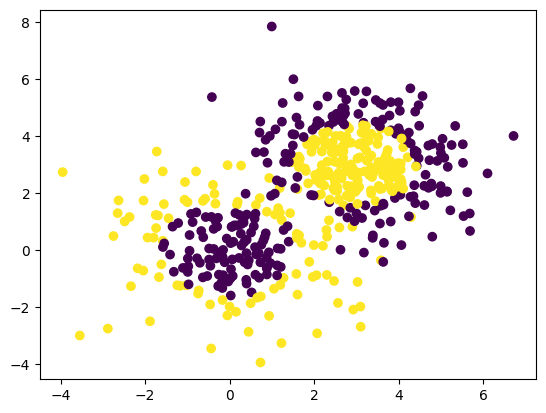

In [7]:
df.columns = ['X', 'Y', 'class']
plt.scatter(x=df['X'],y=df['Y'],c=df['class'])

In [8]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [9]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

In [10]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [12]:
history1 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5163 - loss: 0.6879 - val_accuracy: 0.4300 - val_loss: 0.7301
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5213 - loss: 0.6874 - val_accuracy: 0.4300 - val_loss: 0.7291
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5213 - loss: 0.6869 - val_accuracy: 0.4100 - val_loss: 0.7286
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5213 - loss: 0.6864 - val_accuracy: 0.4200 - val_loss: 0.7280
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5188 - loss: 0.6859 - val_accuracy: 0.4200 - val_loss: 0.7276
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5238 - loss: 0.6854 - val_accuracy: 0.4300 - val_loss: 0.7276
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5313 - loss: 0.6849 - val_accuracy: 0.4300 - val_loss: 0.7278
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5338 - loss: 0.6843 - val_accuracy: 0.4300 -

In [13]:
model = Sequential()

model.add(Dense(3,activation='relu',input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [14]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [15]:
history2 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3709 - loss: 0.8142 - val_accuracy: 0.4700 - val_loss: 0.7054
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4135 - loss: 0.7970 - val_accuracy: 0.5100 - val_loss: 0.6992
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4336 - loss: 0.7872 - val_accuracy: 0.6200 - val_loss: 0.6947
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4662 - loss: 0.7730 - val_accuracy: 0.6100 - val_loss: 0.6919
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4386 - loss: 0.7859 - val_accuracy: 0.6300 - val_loss: 0.6901
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4962 - loss: 0.7583 - val_accuracy: 0.5600 - val_loss: 0.6884
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4862 - loss: 0.7537 - val_accuracy: 0.5700 - val_loss: 0.6877
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4937 - loss: 0.7457 - val_accuracy: 0.5200 - 

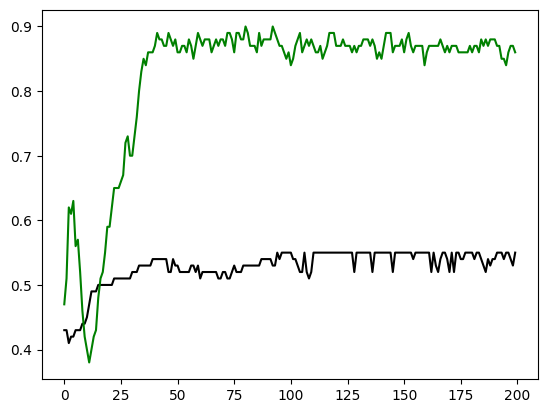

In [16]:
plt.plot(history1.history['val_accuracy'],color='black')
plt.plot(history2.history['val_accuracy'],color='green')